# 🎯 Notebook 19: Predição 2025-Only (Motor Hiper-Inteligente)

Este notebook implementa a estratégia de **Especialização Temporal**, utilizando exclusivamente a base de dados tratada de 2025. 

**Seções:**
1. Ingestão e Integração de Contexto.
2. Treinamento de Comitê Ensemblista (XGB, LGBM, Cat).
3. Margem de Segurança Estatística.
4. **🏆 Competição Final: IA vs Reservas (Placar de Eficiência).**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import os
import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

BASE_PATH = "../data/"
print("✅ Motor 19 pronto para o Duelo de Acurácia.")

✅ Motor 19 pronto para o Duelo de Acurácia.


In [7]:
df_main = pd.read_csv(os.path.join(BASE_PATH, "base_features_selecionadas.csv"))
df_main['data'] = pd.to_datetime(df_main['data'])

df_bert = pd.read_csv(os.path.join(BASE_PATH, "embeddings_bert_cardapio.csv"))
df_bert['data'] = pd.to_datetime(df_bert['data'])

df = pd.merge(df_main, df_bert, on='data', how='inner')
df = df[df['data'].dt.year == 2025].sort_values('data').reset_index(drop=True)

context_cols = ['eh_evento_especial', 'eh_reuniao_impacto', 'vespera_feriado']
if not all(c in df.columns for c in context_cols):
    df_mestra = pd.read_csv(os.path.join(BASE_PATH, "base_features_final.csv"))
    df_mestra['data'] = pd.to_datetime(df_mestra['data'])
    df = pd.merge(df, df_mestra[['data'] + [c for c in context_cols if c in df_mestra.columns]], on='data', how='left').fillna(0)

print(f"📊 Base 2025 Integrada: {len(df)} registros.")

📊 Base 2025 Integrada: 92 registros.


In [8]:
TARGET = 'total_servido' if 'total_servido' in df.columns else 'servida'
exclude = [TARGET, 'data', 'ano', 'base_servida', 'reserva', 'total_reservas', 'Predicao_IA', 'Recomendacao_Producao']
features = [c for c in df.columns if c not in exclude and not (isinstance(c, str) and c.startswith('Unnamed'))]

train_size = len(df) - 15
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
lgb = LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
cat = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=6, verbose=0, random_state=42)

xgb.fit(df_train[features], df_train[TARGET])
lgb.fit(df_train[features], df_train[TARGET])
cat.fit(df_train[features], df_train[TARGET])

p_ia = (xgb.predict(df_test[features]) + lgb.predict(df_test[features]) + cat.predict(df_test[features])) / 3
df_test['Predicao_IA'] = np.ceil((0.7 * p_ia) + (0.3 * df_test['total_reservas']))

# Margem de Segurança
std_error = np.std(df_train[TARGET] - (xgb.predict(df_train[features]) + lgb.predict(df_train[features]) + cat.predict(df_train[features])) / 3)
margem = np.ceil(1.645 * std_error)
df_test['Recomendacao_IA_Segura'] = df_test['Predicao_IA'] + margem

## 🏆 Competição Final: IA vs Reservas Manuais

Nesta seção, comparamos o desempenho do método tradicional (Reservas via App/Manual) contra a nossa Inteligência Artificial especializada em 2025.
Qual método errou menos e qual evitou melhor o desperdício?

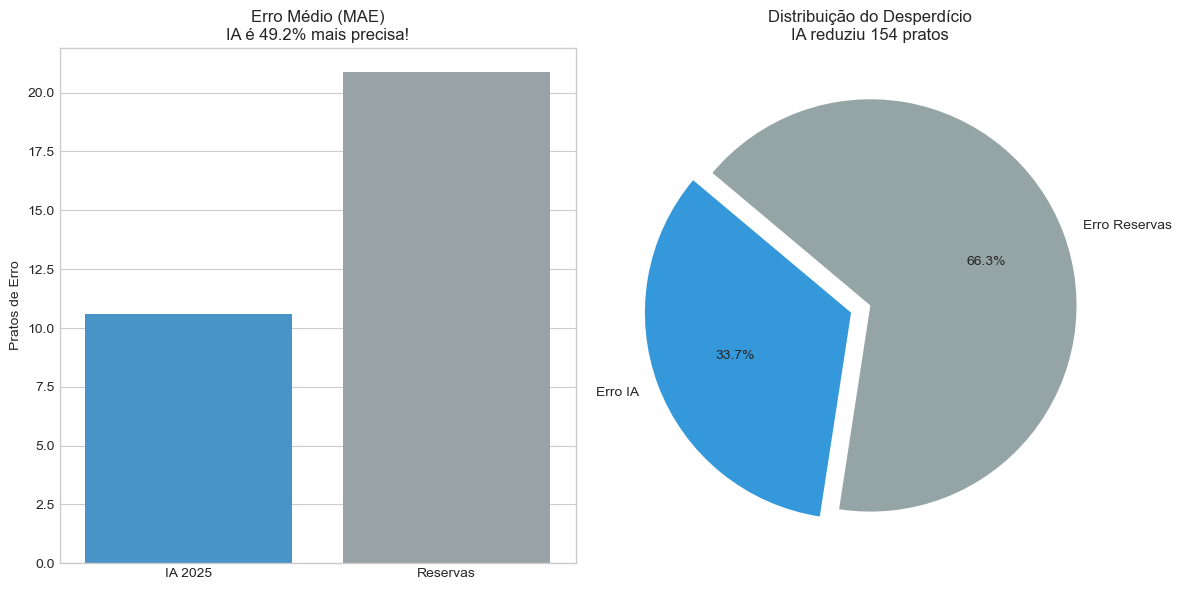

,Métrica,Reservas Manuais,Inteligência Artificial
0,Erro Médio (MAE),20.87,10.60
1,Resíduo Total (Pratos),313,159
2,Estabilidade (R2),0.1670,0.7950


In [9]:
# 1. Cálculo de Erros Médios (MAE)
mae_ia = mean_absolute_error(df_test[TARGET], df_test['Predicao_IA'])
mae_res = mean_absolute_error(df_test[TARGET], df_test['total_reservas'])
melhoria = ((mae_res - mae_ia) / mae_res) * 100

# 2. Placar de Erros Acumulados (Desperdício em Pratos)
total_erro_ia = (df_test['Predicao_IA'] - df_test[TARGET]).abs().sum()
total_erro_res = (df_test['total_reservas'] - df_test[TARGET]).abs().sum()

# 3. Visualização do Duelo
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
colors = ['#3498db', '#95a5a6']
sns.barplot(x=['IA 2025', 'Reservas'], y=[mae_ia, mae_res], palette=colors)
plt.title(f'Erro Médio (MAE)\nIA é {melhoria:.1f}% mais precisa!')
plt.ylabel('Pratos de Erro')

plt.subplot(1, 2, 2)
plt.pie([total_erro_ia, total_erro_res], labels=['Erro IA', 'Erro Reservas'], 
        autopct='%1.1f%%', colors=colors, startangle=140, explode=[0.1, 0])
plt.title(f'Distribuição do Desperdício\nIA reduziu {int(total_erro_res - total_erro_ia)} pratos')

plt.tight_layout()
plt.show()

# Resumo em DataFrame para a Dissertação
placar = pd.DataFrame({
    'Métrica': ['Erro Médio (MAE)', 'Resíduo Total (Pratos)', 'Estabilidade (R2)'],
    'Reservas Manuais': [f"{mae_res:.2f}", f"{int(total_erro_res)}", f"{r2_score(df_test[TARGET], df_test['total_reservas']):.4f}"],
    'Inteligência Artificial': [f"{mae_ia:.2f}", f"{int(total_erro_ia)}", f"{r2_score(df_test[TARGET], df_test['Predicao_IA']):.4f}"]
})
display(placar)

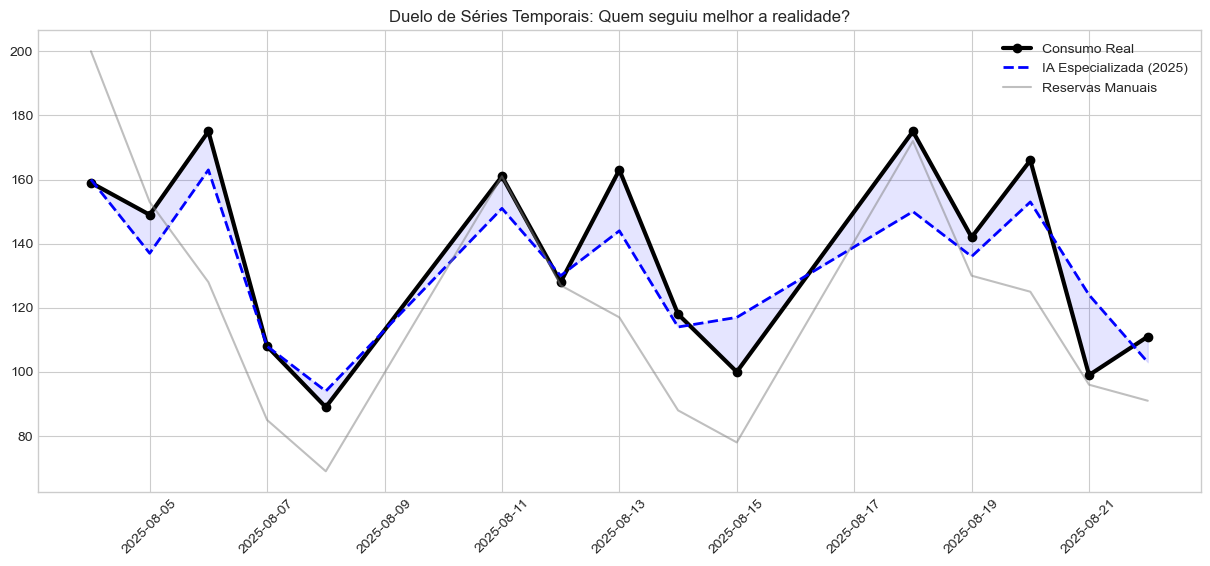

In [10]:
plt.figure(figsize=(15, 6))
plt.plot(df_test['data'], df_test[TARGET], 'k-o', label='Consumo Real', linewidth=3)
plt.plot(df_test['data'], df_test['Predicao_IA'], 'b--', label='IA Especializada (2025)', linewidth=2)
plt.plot(df_test['data'], df_test['total_reservas'], 'grey', alpha=0.5, label='Reservas Manuais')
plt.fill_between(df_test['data'], df_test['Predicao_IA'], df_test[TARGET], color='blue', alpha=0.1)
plt.title('Duelo de Séries Temporais: Quem seguiu melhor a realidade?')
plt.legend()
plt.xticks(rotation=45)
plt.show()